# EEG Power Analysis by Frequency Bands and Tasks

This notebook analyzes the time-series power changes in different frequency bands (alpha, beta, theta, delta) for different motor imagery tasks.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle
from matplotlib.colors import TwoSlopeNorm

import mne
from mne.datasets import eegbci
from mne.io import concatenate_raws, read_raw_edf
from mne.time_frequency import psd_array_welch

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [3]:
# Load preprocessed EEG data
data_file_path = "../../data/20250604/processed/20250604_1_ishii_ica_epochs.pkl"
# data_file_path = "../../data/20250604/processed/20250604_2_Ishii_ica_epochs.pkl"

event_ids = {1: 'task1', 2: 'task2'}  # map event IDs to tasks

# Load pickled EEG data
with open(data_file_path, 'rb') as f:
    data = pickle.load(f)

epochs = data['epochs']  # epoch data
labels = data['labels']   # labels

# Select channels and resample
epochs.pick_channels(["C3", "Cz", "C4"])  # Select motor cortex channels
epochs.resample(500)  # Resample to 500Hz

print(f"Epochs shape: {epochs.get_data().shape}")
print(f"Sampling frequency: {epochs.info['sfreq']} Hz")
print(f"Time range: {epochs.tmin} to {epochs.tmax} seconds")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Epochs shape: (60, 3, 2500)
Sampling frequency: 500.0 Hz
Time range: -1.0 to 3.998 seconds


In [4]:
# Define frequency bands
freq_bands = {
    'delta': (1, 4),
    'theta': (4, 8), 
    'alpha': (8, 13),
    'beta': (13, 30)
}

# Time parameters
sfreq = epochs.info['sfreq']
n_times = epochs.get_data().shape[-1]
times = epochs.times

print(f"Frequency bands: {freq_bands}")
print(f"Time points: {n_times}")
print(f"Time vector shape: {times.shape}")

Frequency bands: {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30)}
Time points: 2500
Time vector shape: (2500,)


In [5]:
def compute_band_power_timeseries(epochs_data, sfreq, freq_bands, nperseg=256, noverlap=128):
    """
    Compute power time series for different frequency bands using sliding window approach.
    
    Parameters:
    -----------
    epochs_data : array, shape (n_epochs, n_channels, n_times)
        EEG epoch data
    sfreq : float
        Sampling frequency
    freq_bands : dict
        Dictionary with band names as keys and (low_freq, high_freq) tuples as values
    nperseg : int
        Length of each segment for spectrogram
    noverlap : int
        Number of points to overlap between segments
        
    Returns:
    --------
    power_data : dict
        Dictionary containing power time series for each band
    time_vec : array
        Time vector for the power time series
    """
    n_epochs, n_channels, n_times = epochs_data.shape
    
    # Compute spectrogram for all epochs and channels
    from scipy import signal
    
    # Initialize storage
    power_data = {band: [] for band in freq_bands.keys()}
    
    for epoch_idx in range(n_epochs):
        epoch_powers = {band: [] for band in freq_bands.keys()}
        
        for ch_idx in range(n_channels):
            # Compute spectrogram
            freqs, times_spec, Sxx = signal.spectrogram(
                epochs_data[epoch_idx, ch_idx, :], 
                fs=sfreq, 
                nperseg=nperseg, 
                noverlap=noverlap
            )
            
            # Extract power for each frequency band
            for band_name, (low_freq, high_freq) in freq_bands.items():
                # Find frequency indices
                freq_mask = (freqs >= low_freq) & (freqs <= high_freq)
                
                # Compute band power (sum across frequencies)
                band_power = np.sum(Sxx[freq_mask, :], axis=0)
                epoch_powers[band_name].append(band_power)
        
        # Stack channels for this epoch
        for band_name in freq_bands.keys():
            power_data[band_name].append(np.array(epoch_powers[band_name]))
    
    # Convert to arrays
    for band_name in freq_bands.keys():
        power_data[band_name] = np.array(power_data[band_name])
    
    return power_data, times_spec

# Compute power time series
epochs_data = epochs.get_data()
power_data, time_vec = compute_band_power_timeseries(epochs_data, sfreq, freq_bands)

print("Power data shapes:")
for band, data in power_data.items():
    print(f"{band}: {data.shape} (epochs, channels, time_points)")
print(f"Time vector shape: {time_vec.shape}")

Power data shapes:
delta: (60, 3, 18) (epochs, channels, time_points)
theta: (60, 3, 18) (epochs, channels, time_points)
alpha: (60, 3, 18) (epochs, channels, time_points)
beta: (60, 3, 18) (epochs, channels, time_points)
Time vector shape: (18,)


In [6]:
# Create comprehensive DataFrame for analysis
def create_power_dataframe(power_data, time_vec, labels, channel_names, epochs):
    """
    Create a pandas DataFrame from power data for easy analysis and visualization.
    """
    data_list = []
    
    for band_name, band_data in power_data.items():
        n_epochs, n_channels, n_times = band_data.shape
        
        for epoch_idx in range(n_epochs):
            # Get task label for this epoch
            task_label = event_ids.get(labels[epoch_idx], f'task_{labels[epoch_idx]}')
            
            for ch_idx, channel in enumerate(channel_names):
                for time_idx, time_point in enumerate(time_vec):
                    # Adjust time to match original epoch timing
                    adjusted_time = epochs.tmin + time_point
                    
                    data_list.append({
                        'epoch': epoch_idx,
                        'task': task_label,
                        'channel': channel,
                        'band': band_name,
                        'time': adjusted_time,
                        'power': band_data[epoch_idx, ch_idx, time_idx]
                    })
    
    return pd.DataFrame(data_list)

# Create DataFrame
channel_names = epochs.ch_names
df_power = create_power_dataframe(power_data, time_vec, labels, channel_names, epochs)

print(f"DataFrame shape: {df_power.shape}")
print("\nFirst few rows:")
print(df_power.head())

print("\nUnique values:")
print(f"Tasks: {df_power['task'].unique()}")
print(f"Channels: {df_power['channel'].unique()}")
print(f"Bands: {df_power['band'].unique()}")

DataFrame shape: (12960, 6)

First few rows:
   epoch   task channel   band   time         power
0      0  task1      C3  delta -0.744  5.112075e-12
1      0  task1      C3  delta -0.488  6.610169e-12
2      0  task1      C3  delta -0.232  5.979462e-12
3      0  task1      C3  delta  0.024  2.193940e-12
4      0  task1      C3  delta  0.280  9.699612e-12

Unique values:
Tasks: ['task1' 'task2']
Channels: ['C3' 'Cz' 'C4']
Bands: ['delta' 'theta' 'alpha' 'beta']


/tmp/ipykernel_95228/1172592920.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_95228/1172592920.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_95228/1172592920.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_95228/1172592920.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


<Figure size 1500x1000 with 0 Axes>

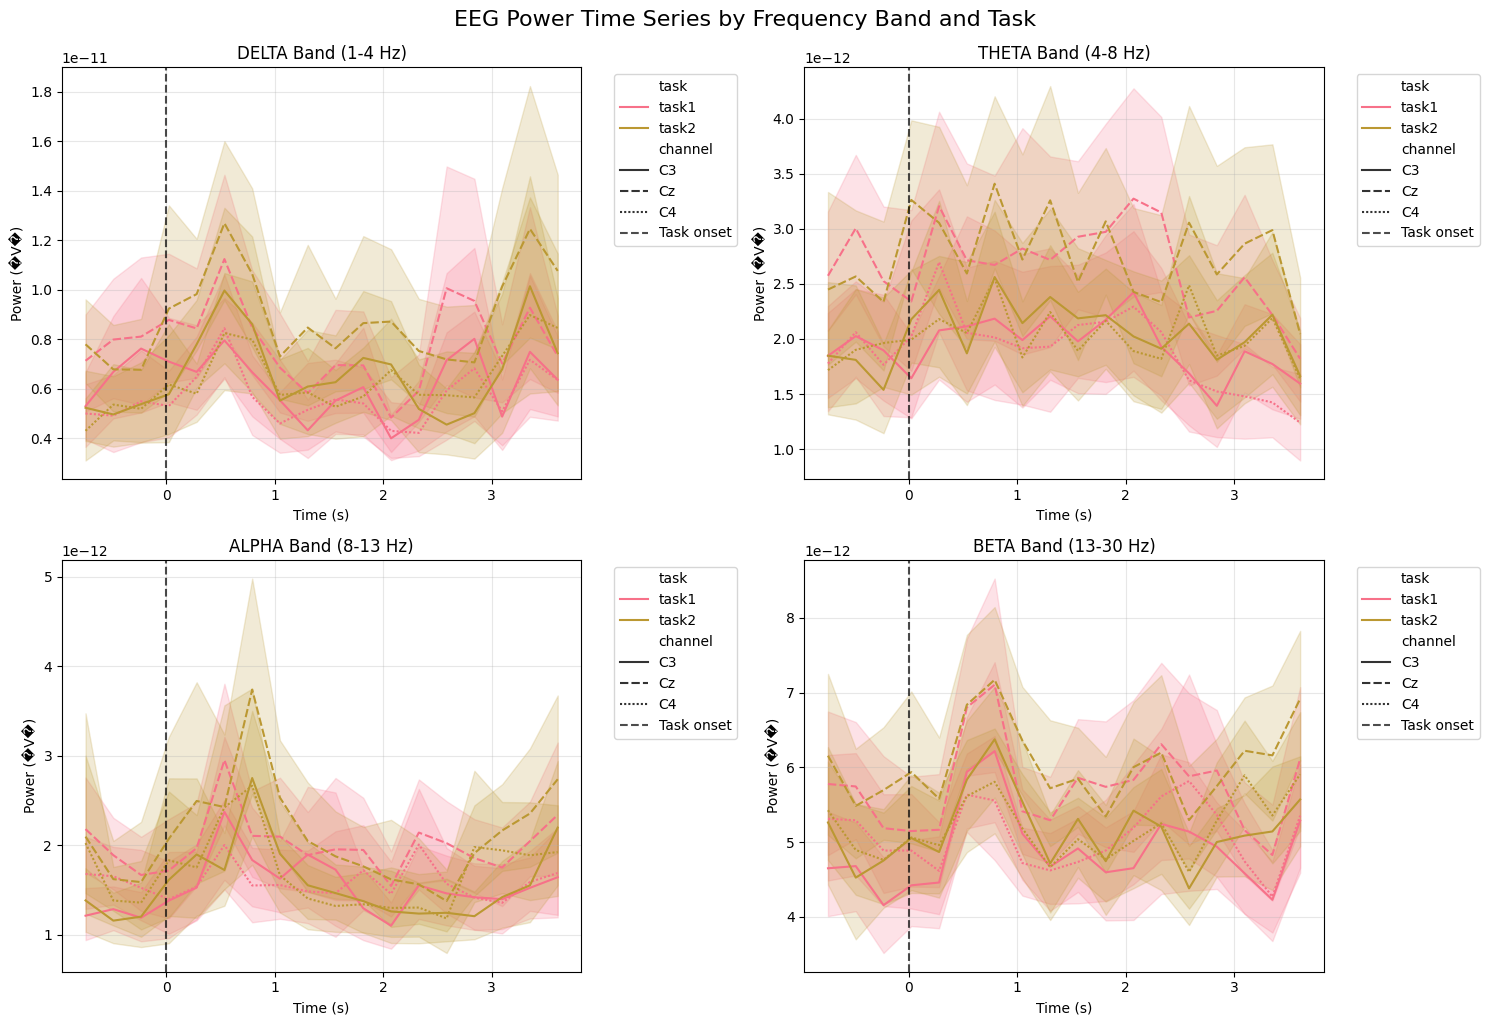

In [7]:
# Plot 1: Power time series by frequency band and task
plt.figure(figsize=(15, 10))

# Create subplots for each frequency band
bands = list(freq_bands.keys())
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, band in enumerate(bands):
    ax = axes[idx]
    
    # Filter data for this band
    band_data = df_power[df_power['band'] == band]
    
    # Plot time series for each task and channel
    sns.lineplot(
        data=band_data, 
        x='time', 
        y='power', 
        hue='task', 
        style='channel',
        ax=ax,
        ci=95  # 95% confidence interval
    )
    
    ax.set_title(f'{band.upper()} Band ({freq_bands[band][0]}-{freq_bands[band][1]} Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power (�V�)')
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Task onset')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('EEG Power Time Series by Frequency Band and Task', y=1.02, fontsize=16)
plt.show()

/tmp/ipykernel_95228/4255615655.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_95228/4255615655.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/tmp/ipykernel_95228/4255615655.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


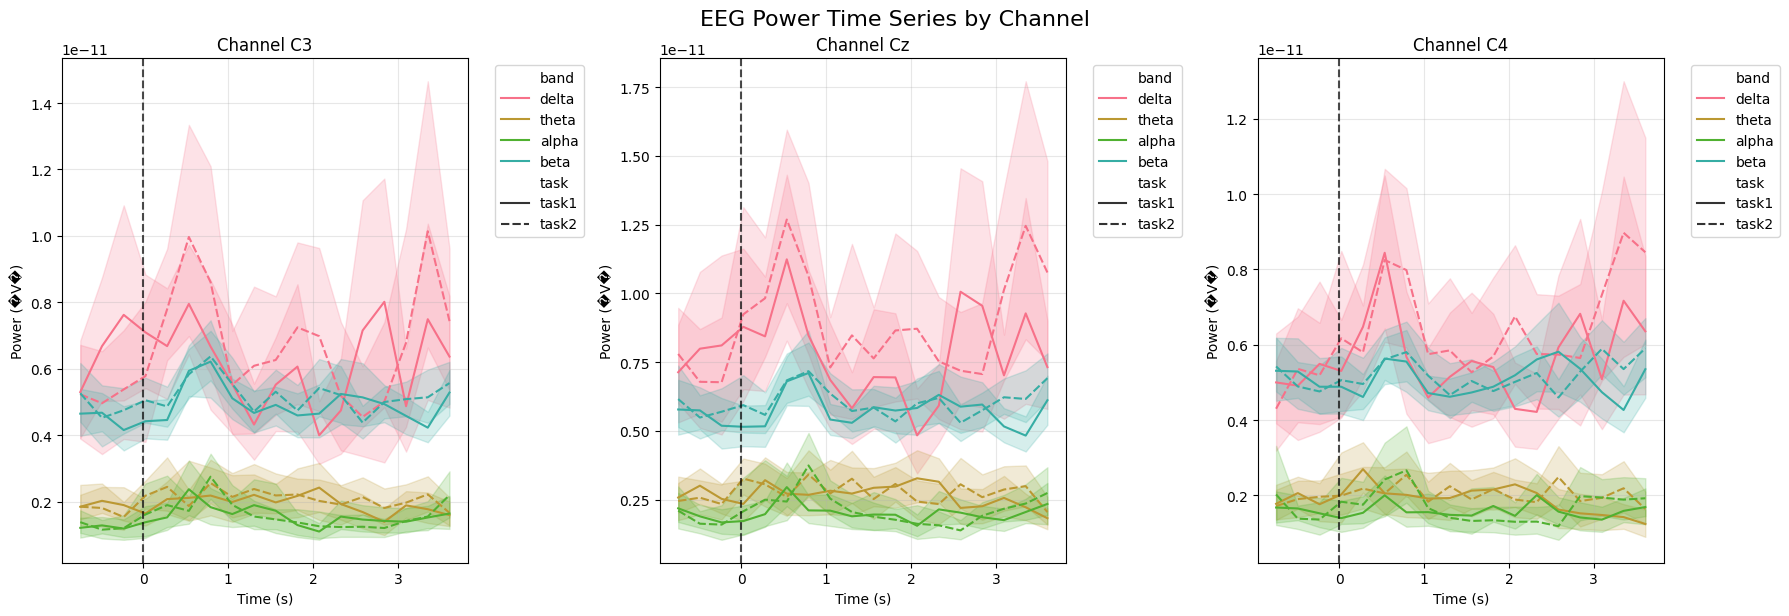

In [8]:
# Plot 2: Channel-specific power comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, channel in enumerate(channel_names):
    ax = axes[idx]
    
    # Filter data for this channel
    channel_data = df_power[df_power['channel'] == channel]
    
    # Plot power time series for each band and task
    sns.lineplot(
        data=channel_data,
        x='time',
        y='power',
        hue='band',
        style='task',
        ax=ax,
        ci=95
    )
    
    ax.set_title(f'Channel {channel}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power (�V�)')
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('EEG Power Time Series by Channel', y=1.02, fontsize=16)
plt.show()

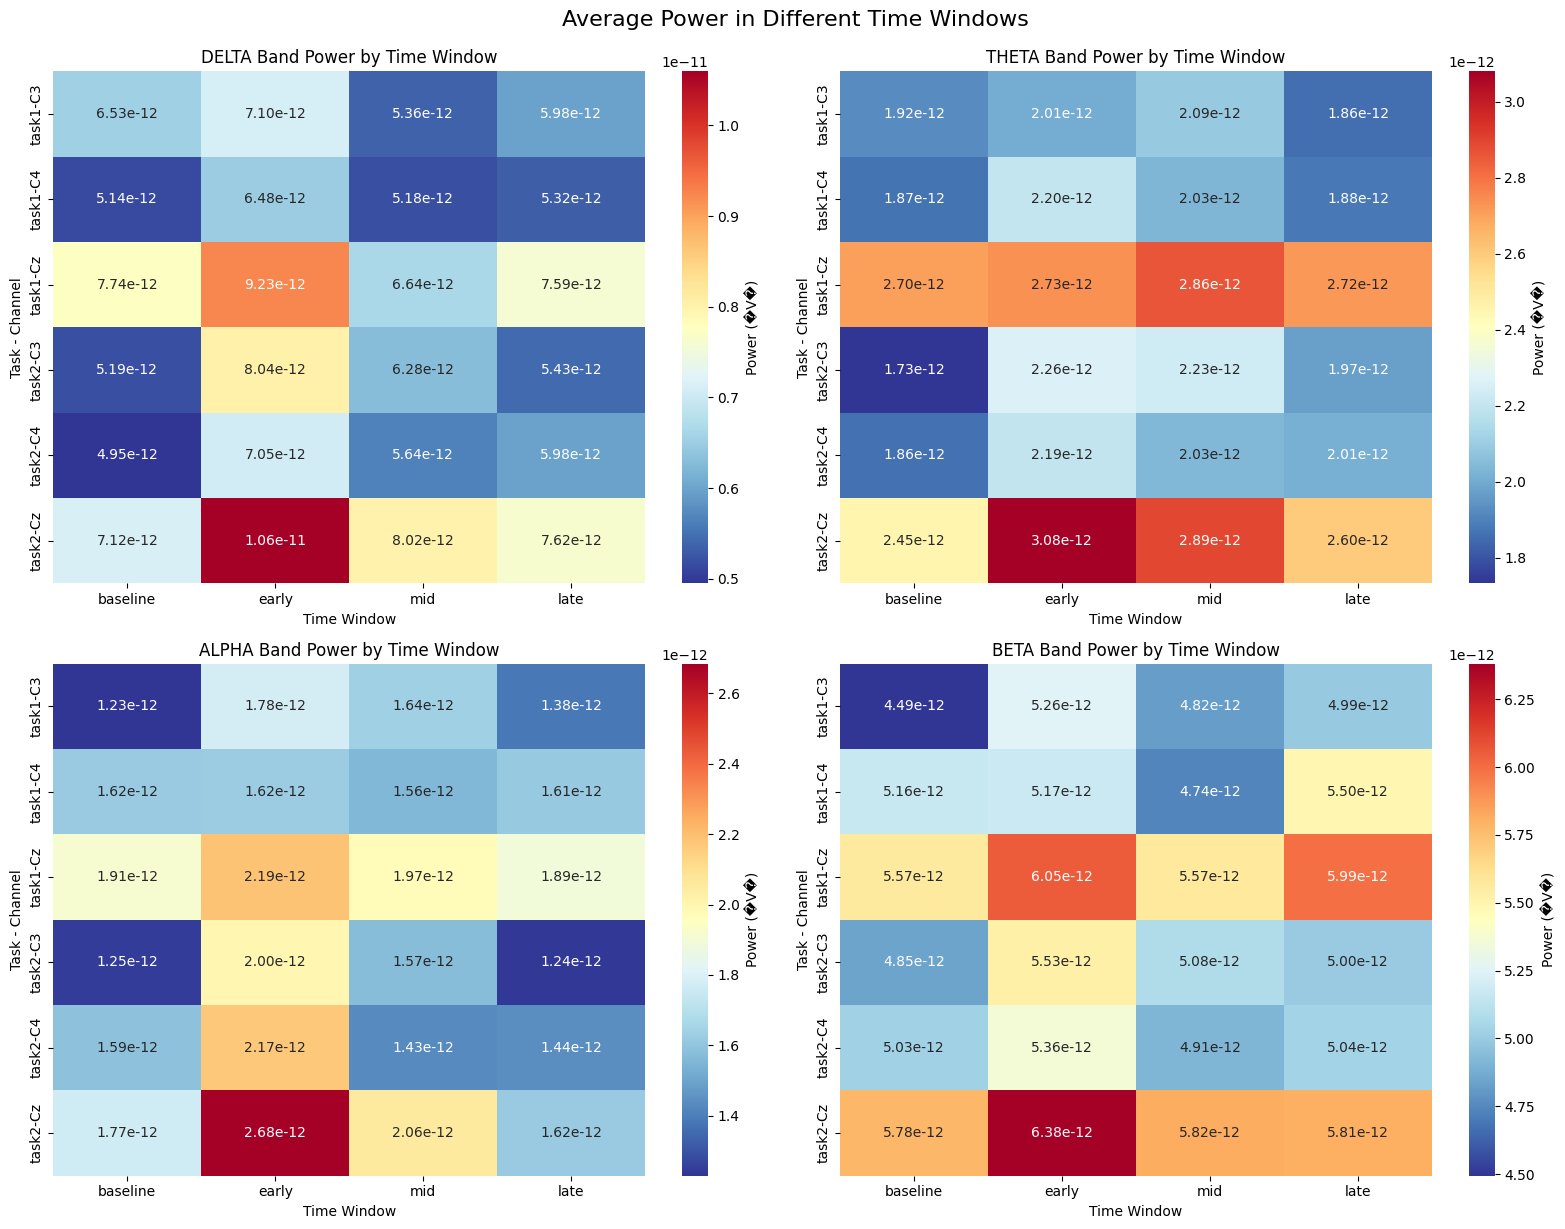

In [9]:
# Plot 3: Task comparison heatmap
# Compute average power in different time windows
time_windows = {
    'baseline': (-1.0, 0.0),
    'early': (0.0, 1.0),
    'mid': (1.0, 2.0),
    'late': (2.0, 3.0)
}

def compute_windowed_power(df, time_windows):
    """
    Compute average power in specified time windows.
    """
    windowed_data = []
    
    for window_name, (t_start, t_end) in time_windows.items():
        # Filter data for this time window
        window_data = df[(df['time'] >= t_start) & (df['time'] <= t_end)]
        
        # Compute mean power for each combination
        window_summary = window_data.groupby(['task', 'channel', 'band'])['power'].mean().reset_index()
        window_summary['time_window'] = window_name
        
        windowed_data.append(window_summary)
    
    return pd.concat(windowed_data, ignore_index=True)

windowed_power = compute_windowed_power(df_power, time_windows)

# Create heatmap
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, band in enumerate(bands):
    ax = axes[idx]
    
    # Prepare data for heatmap
    band_windowed = windowed_power[windowed_power['band'] == band]
    heatmap_data = band_windowed.pivot_table(
        values='power', 
        index=['task', 'channel'], 
        columns='time_window'
    )
    
    # Reorder columns to match time progression
    column_order = ['baseline', 'early', 'mid', 'late']
    heatmap_data = heatmap_data.reindex(columns=column_order)
    
    # Create heatmap
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.2e',
        cmap='RdYlBu_r',
        ax=ax,
        cbar_kws={'label': 'Power (�V�)'}
    )
    
    ax.set_title(f'{band.upper()} Band Power by Time Window')
    ax.set_xlabel('Time Window')
    ax.set_ylabel('Task - Channel')

plt.tight_layout()
plt.suptitle('Average Power in Different Time Windows', y=1.02, fontsize=16)
plt.show()

In [10]:
# Statistical analysis: Compare power between tasks
from scipy import stats

def compare_tasks_statistical(df, time_window=(0.5, 2.5)):
    """
    Perform statistical comparison between tasks for each band and channel.
    """
    # Filter data for analysis time window
    analysis_data = df[(df['time'] >= time_window[0]) & (df['time'] <= time_window[1])]
    
    # Compute average power per epoch for statistical testing
    epoch_averages = analysis_data.groupby(['epoch', 'task', 'channel', 'band'])['power'].mean().reset_index()
    
    results = []
    
    for band in epoch_averages['band'].unique():
        for channel in epoch_averages['channel'].unique():
            # Get data for this band-channel combination
            subset = epoch_averages[(epoch_averages['band'] == band) & (epoch_averages['channel'] == channel)]
            
            # Separate by task
            tasks = subset['task'].unique()
            if len(tasks) == 2:
                task1_data = subset[subset['task'] == tasks[0]]['power'].values
                task2_data = subset[subset['task'] == tasks[1]]['power'].values
                
                # Perform t-test
                t_stat, p_value = stats.ttest_ind(task1_data, task2_data)
                
                results.append({
                    'band': band,
                    'channel': channel,
                    'task1': tasks[0],
                    'task2': tasks[1],
                    'task1_mean': np.mean(task1_data),
                    'task2_mean': np.mean(task2_data),
                    't_statistic': t_stat,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })
    
    return pd.DataFrame(results)

# Perform statistical analysis
stats_results = compare_tasks_statistical(df_power)

print("Statistical Comparison Results:")
print("=" * 50)
for _, row in stats_results.iterrows():
    sig_marker = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"{row['band'].upper()} - {row['channel']}: {row['task1']} vs {row['task2']}")
    print(f"  Means: {row['task1_mean']:.2e} vs {row['task2_mean']:.2e}")
    print(f"  t = {row['t_statistic']:.3f}, p = {row['p_value']:.4f} {sig_marker}")
    print()

# Summary of significant results
significant_results = stats_results[stats_results['significant']]
print(f"\nSignificant differences found in {len(significant_results)} out of {len(stats_results)} comparisons.")
if len(significant_results) > 0:
    print("\nSignificant comparisons:")
    for _, row in significant_results.iterrows():
        print(f"- {row['band'].upper()} band in {row['channel']}: p = {row['p_value']:.4f}")

Statistical Comparison Results:
ALPHA - C3: task1 vs task2
  Means: 1.68e-12 vs 1.66e-12
  t = 0.099, p = 0.9216 

ALPHA - C4: task1 vs task2
  Means: 1.66e-12 vs 1.68e-12
  t = -0.118, p = 0.9067 

ALPHA - Cz: task1 vs task2
  Means: 2.08e-12 vs 2.20e-12
  t = -0.549, p = 0.5854 

BETA - C3: task1 vs task2
  Means: 5.17e-12 vs 5.39e-12
  t = -0.807, p = 0.4228 

BETA - C4: task1 vs task2
  Means: 5.12e-12 vs 5.17e-12
  t = -0.215, p = 0.8309 

BETA - Cz: task1 vs task2
  Means: 6.04e-12 vs 6.18e-12
  t = -0.435, p = 0.6649 

DELTA - C3: task1 vs task2
  Means: 5.60e-12 vs 6.98e-12
  t = -1.953, p = 0.0557 

DELTA - C4: task1 vs task2
  Means: 5.42e-12 vs 6.41e-12
  t = -1.904, p = 0.0619 

DELTA - Cz: task1 vs task2
  Means: 7.13e-12 vs 8.95e-12
  t = -2.391, p = 0.0200 *

THETA - C3: task1 vs task2
  Means: 2.13e-12 vs 2.16e-12
  t = -0.165, p = 0.8694 

THETA - C4: task1 vs task2
  Means: 2.07e-12 vs 2.06e-12
  t = 0.071, p = 0.9437 

THETA - Cz: task1 vs task2
  Means: 2.91e-12 vs 

In [11]:
# Save results
output_data = {
    'power_dataframe': df_power,
    'windowed_power': windowed_power,
    'statistical_results': stats_results,
    'freq_bands': freq_bands,
    'channel_names': channel_names,
    'time_vector': time_vec
}

# Save to pickle file
output_path = "power_analysis_results.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(output_data, f)

print(f"Results saved to: {output_path}")

# Also save statistical results as CSV for easy viewing
stats_results.to_csv('statistical_comparison_results.csv', index=False)
windowed_power.to_csv('windowed_power_analysis.csv', index=False)

print("Analysis complete!")
print(f"- Power time series data shape: {df_power.shape}")
print(f"- Statistical comparisons: {len(stats_results)}")
print(f"- Significant differences: {len(stats_results[stats_results['significant']])}")

Results saved to: power_analysis_results.pkl
Analysis complete!
- Power time series data shape: (12960, 6)
- Statistical comparisons: 12
- Significant differences: 1


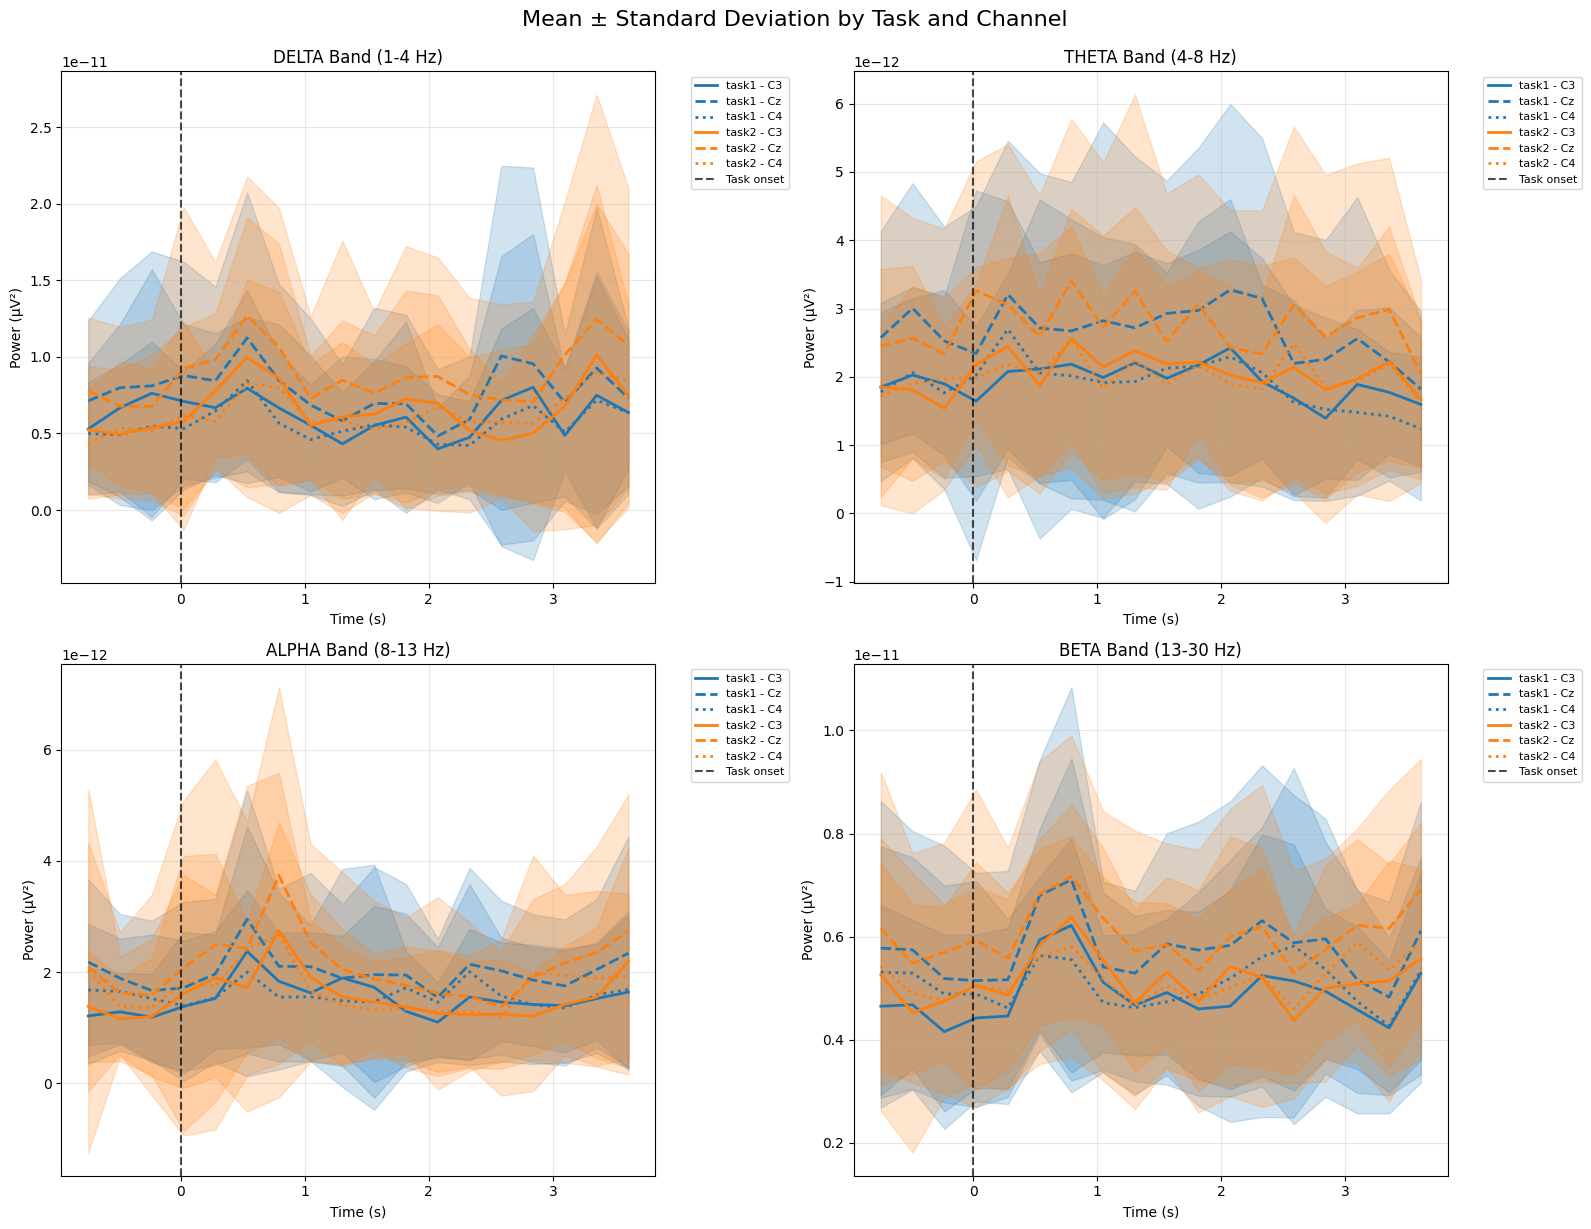

In [12]:
# Plot 4: Task-specific mean and standard deviation visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, band in enumerate(bands):
    ax = axes[idx]
    
    # Filter data for this band
    band_data = df_power[df_power['band'] == band]
    
    # Compute mean and std for each task and channel across epochs
    stats_data = band_data.groupby(['task', 'channel', 'time'])['power'].agg(['mean', 'std']).reset_index()
    
    # Plot for each task
    for task in stats_data['task'].unique():
        task_data = stats_data[stats_data['task'] == task]
        
        for channel in channel_names:
            channel_task_data = task_data[task_data['channel'] == channel]
            
            # Create unique color and linestyle for each task-channel combination
            color = plt.cm.tab10(list(stats_data['task'].unique()).index(task))
            linestyle = ['-', '--', ':'][channel_names.index(channel)]
            
            # Plot mean line
            ax.plot(channel_task_data['time'], channel_task_data['mean'], 
                   color=color, linestyle=linestyle, linewidth=2,
                   label=f'{task} - {channel}')
            
            # Plot standard deviation as shaded area
            ax.fill_between(channel_task_data['time'], 
                           channel_task_data['mean'] - channel_task_data['std'],
                           channel_task_data['mean'] + channel_task_data['std'],
                           color=color, alpha=0.2)
    
    ax.set_title(f'{band.upper()} Band ({freq_bands[band][0]}-{freq_bands[band][1]} Hz)')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Power (μV²)')
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7, label='Task onset')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Mean ± Standard Deviation by Task and Channel', y=1.02, fontsize=16)
plt.show()

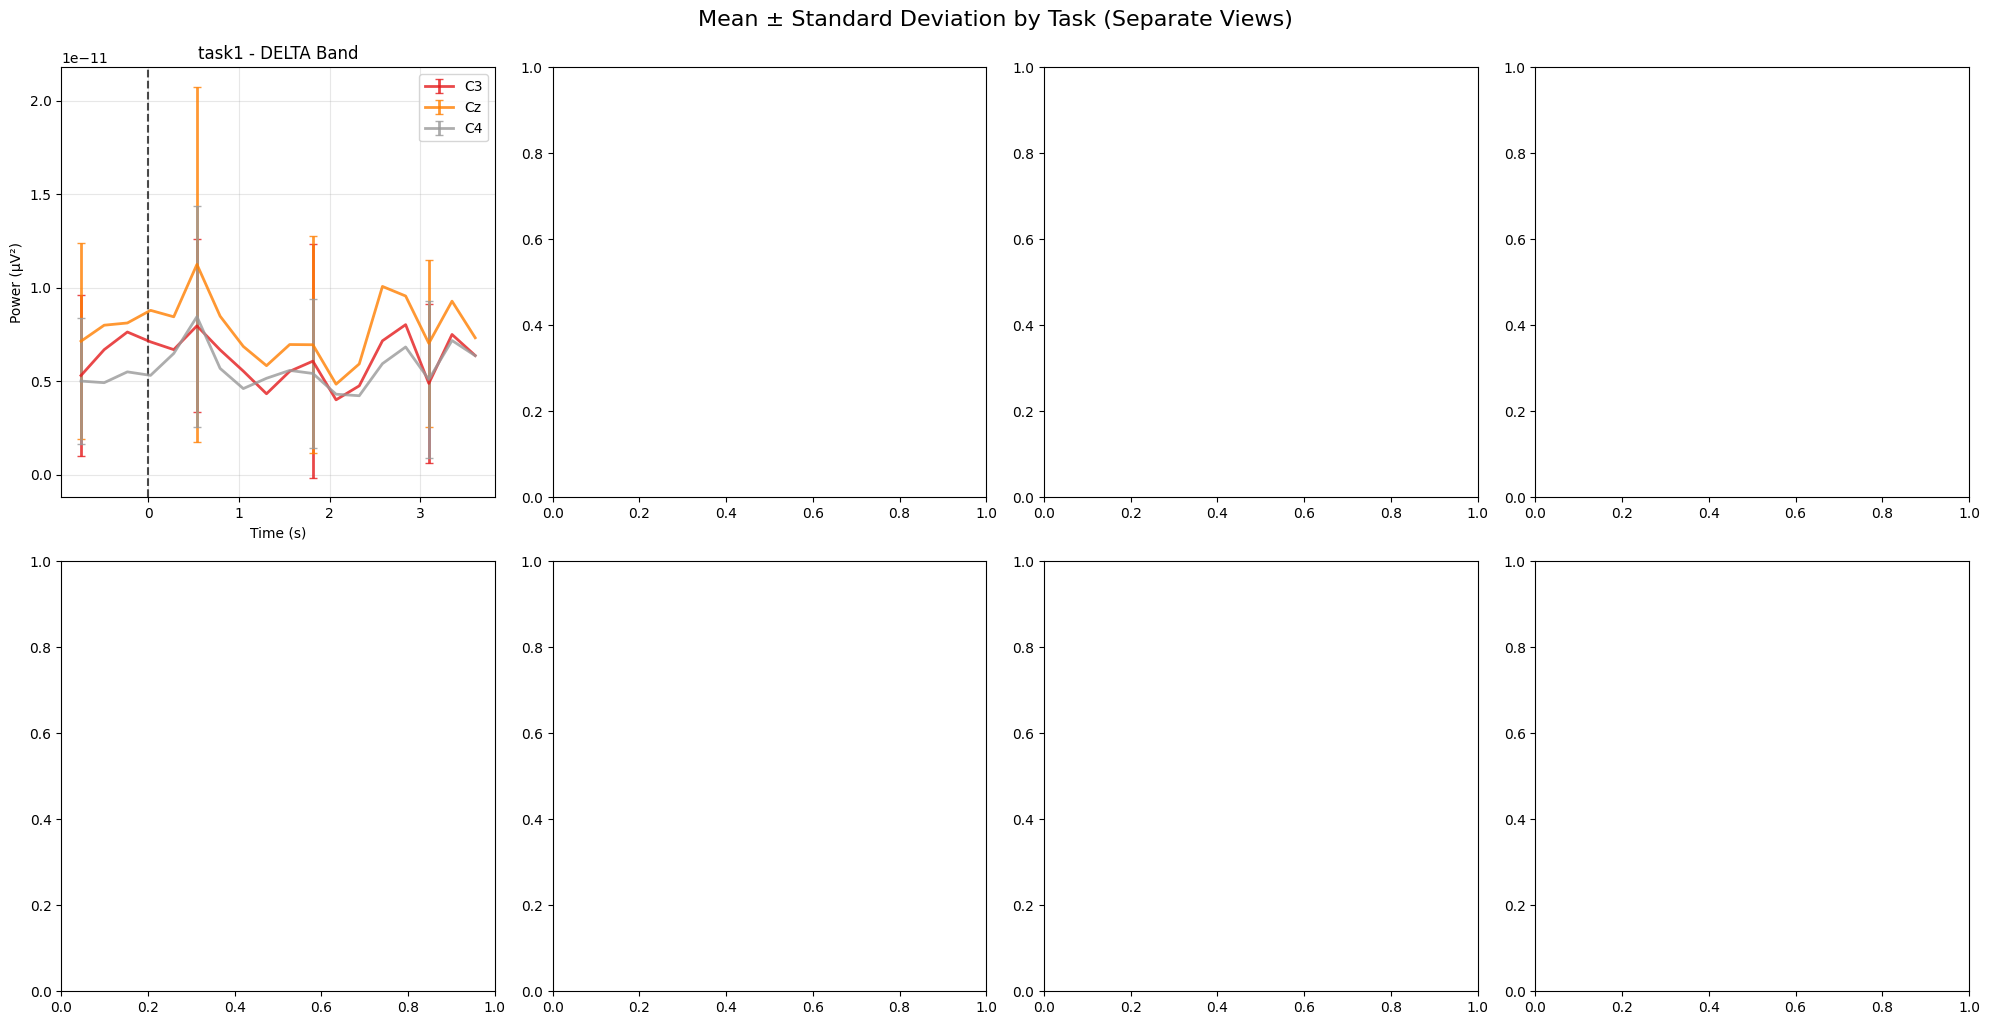

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [13]:
# Plot 5: Alternative visualization - Separate plots for each task
fig, axes = plt.subplots(len(df_power['task'].unique()), len(bands), figsize=(20, 10))

if len(df_power['task'].unique()) == 1:
    axes = axes.reshape(1, -1)

tasks = df_power['task'].unique()

for task_idx, task in enumerate(tasks):
    for band_idx, band in enumerate(bands):
        ax = axes[task_idx, band_idx]
        
        # Filter data for this task and band
        task_band_data = df_power[(df_power['task'] == task) & (df_power['band'] == band)]
        
        # Compute mean and std for each channel
        stats_data = task_band_data.groupby(['channel', 'time'])['power'].agg(['mean', 'std']).reset_index()
        
        # Plot for each channel
        colors = plt.cm.Set1(np.linspace(0, 1, len(channel_names)))
        
        for ch_idx, channel in enumerate(channel_names):
            channel_data = stats_data[stats_data['channel'] == channel]
            
            # Plot mean line with error bars
            ax.errorbar(channel_data['time'], channel_data['mean'], 
                       yerr=channel_data['std'], 
                       color=colors[ch_idx], linewidth=2, alpha=0.8,
                       label=f'{channel}', capsize=3, errorevery=5)
        
        ax.set_title(f'{task} - {band.upper()} Band')
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Power (μV²)')
        ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.suptitle('Mean ± Standard Deviation by Task (Separate Views)', y=1.02, fontsize=16)
        plt.show()

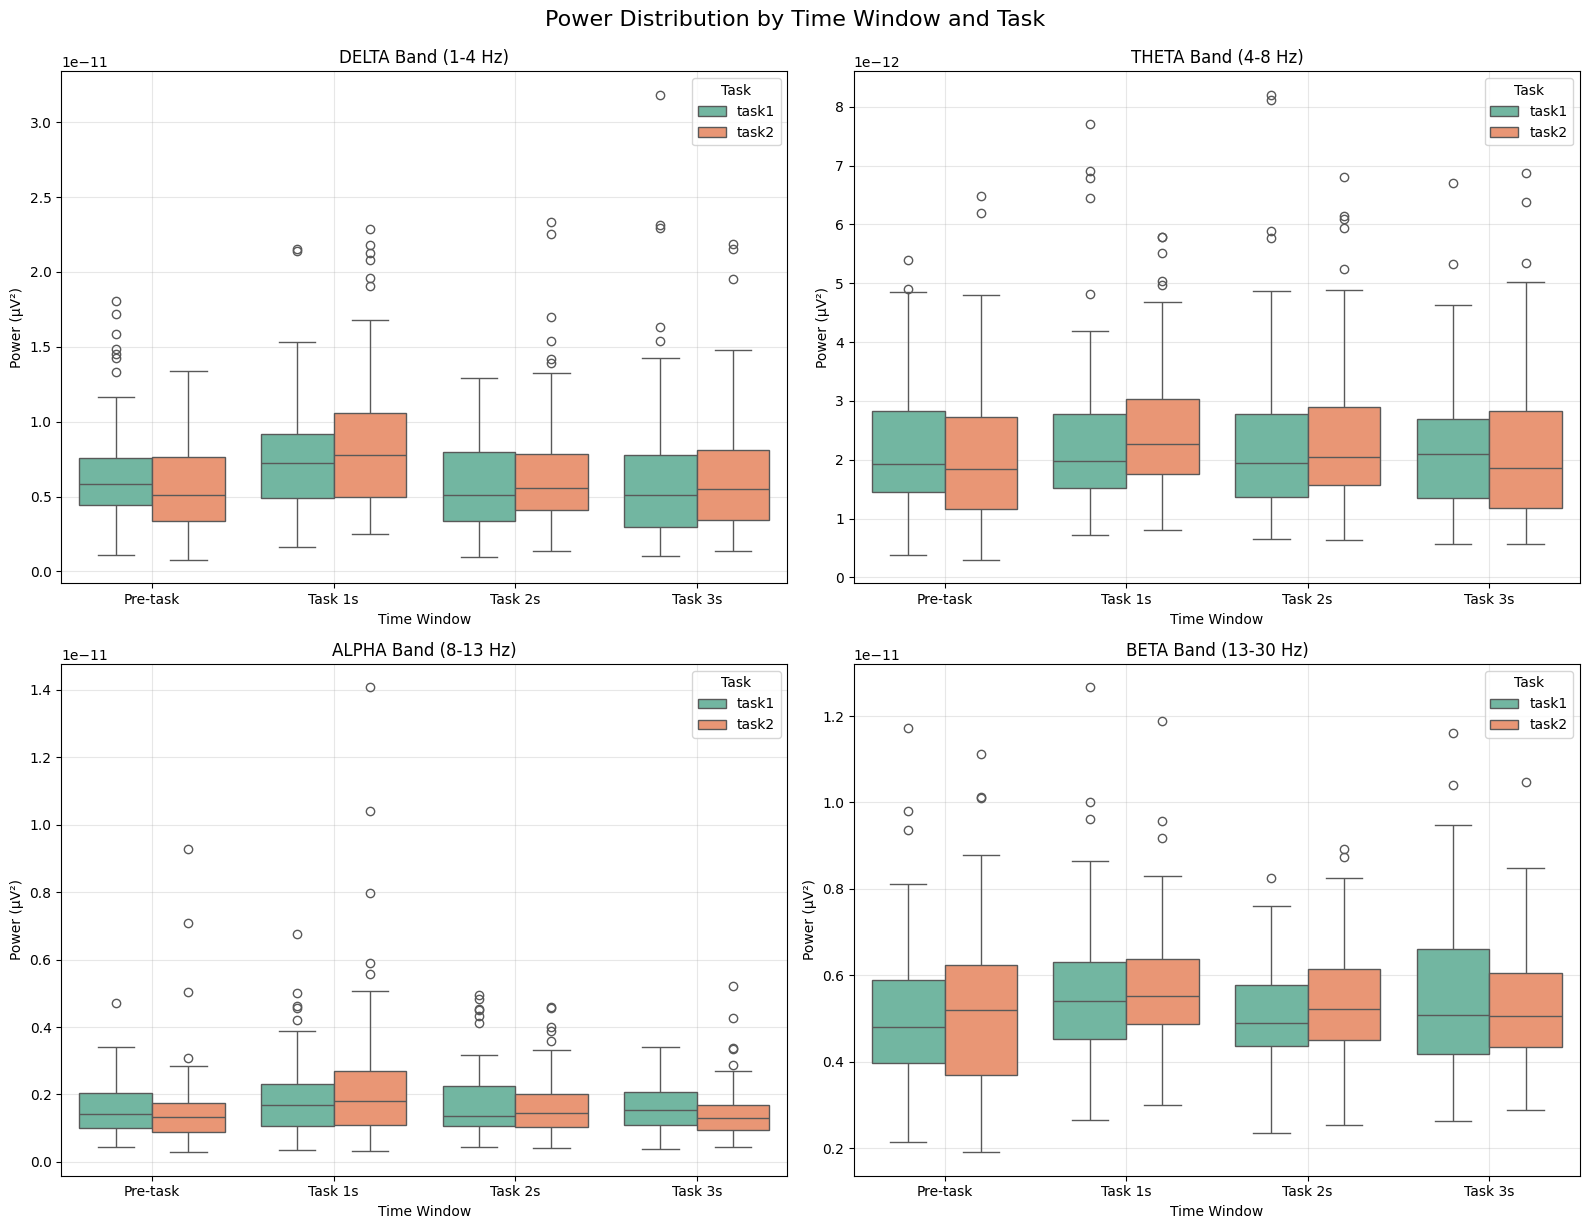

In [14]:
# Plot 6: Box plots showing distribution across time windows by task
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Define time windows for analysis
analysis_windows = {
    'Pre-task': (-1.0, 0.0),
    'Task 1s': (0.0, 1.0), 
    'Task 2s': (1.0, 2.0),
    'Task 3s': (2.0, 3.0)
}

for idx, band in enumerate(bands):
    ax = axes[idx]
    
    # Prepare data for box plot
    box_data = []
    
    for window_name, (t_start, t_end) in analysis_windows.items():
        # Filter data for this band and time window
        window_data = df_power[
            (df_power['band'] == band) & 
            (df_power['time'] >= t_start) & 
            (df_power['time'] <= t_end)
        ]
        
        # Group by epoch and task to get one value per epoch
        epoch_data = window_data.groupby(['epoch', 'task', 'channel'])['power'].mean().reset_index()
        epoch_data['time_window'] = window_name
        box_data.append(epoch_data)
    
    # Combine all time windows
    combined_data = pd.concat(box_data, ignore_index=True)
    
    # Create box plot
    sns.boxplot(data=combined_data, x='time_window', y='power', 
                hue='task', ax=ax, palette='Set2')
    
    ax.set_title(f'{band.upper()} Band ({freq_bands[band][0]}-{freq_bands[band][1]} Hz)')
    ax.set_xlabel('Time Window')
    ax.set_ylabel('Power (μV²)')
    ax.legend(title='Task')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Power Distribution by Time Window and Task', y=1.02, fontsize=16)
plt.show()